In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import mysql.connector

conn=mysql.connector.connect(
    host="localhost",
    user="root",
    password="Root123",
    database="ev_sales")
print("Connected successfully")

Connected successfully


In [3]:
query="show tables;"
tables=pd.read_sql(query,conn)
tables

C:\Users\acer\AppData\Local\Temp\ipykernel_8088\3591082440.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables=pd.read_sql(query,conn)


,Tables_in_ev_sales
0,ev
1,ev data


In [4]:
query="select*from ev data"
df=pd.read_sql(query,conn)
df.head()

C:\Users\acer\AppData\Local\Temp\ipykernel_8088\3638732052.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,3.900000e-04
1,Australia,Historical,EV stock share,Cars,EV,2011,percent,3.900000e-04
2,Australia,Projection-APS,EV stock,Cars,EV,2011,Vehicles,9.000000e+03
3,Europe,Projection-APS,EV stock,Cars,EV,2011,percent,6.500000e-03
4,Australia,Historical,EV sales,Cars,BEV,2022,Vehicles,1.600000e+06


In [5]:
df.head(10)

,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,3.900000e-04
1,Australia,Historical,EV stock share,Cars,EV,2011,percent,3.900000e-04
2,Australia,Projection-APS,EV stock,Cars,EV,2011,Vehicles,9.000000e+03
3,Europe,Projection-APS,EV stock,Cars,EV,2011,percent,6.500000e-03
4,Australia,Historical,EV sales,Cars,BEV,2022,Vehicles,1.600000e+06
5,Europe,Projection-APS,EV stock,Cars,BEV,2011,Vehicles,4.900000e+01
6,Australia,Historical,EV stock,Cars,BEV,2022,Vehicles,4.400000e+06
7,Europe,Projection-APS,EV sales,Cars,BEV,2011,Vehicles,4.900000e+01
8,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,2.200000e+02
9,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,2.200000e+02


In [6]:
df.tail(10)

,region,category,parameter,mode,powertrain,year,unit,value
16768,Poland,Historical,EV sales share,Vans,EV,2017,percent,4.700000e-02
16769,World,Projection-STEPS,EV stock share,Vans,EV,2035,percent,1.800000e+01
16770,World,Projection-STEPS,EV stock share,Buses,EV,2017,percent,5.500000e-02
16771,Poland,Historical,EV stock share,Cars,EV,2017,percent,1.400000e-02
16772,Poland,Historical,EV stock share,Cars,EV,2035,percent,5.500000e+01
16773,World,Projection-STEPS,EV stock share,Cars,EV,2035,percent,3.100000e+01
16774,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,9.400000e+06
16775,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,6.400000e+02
16776,Poland,Projection-APS,EV charging points,EV,Publicly available slow,2035,charging points,1.500000e+07
16777,World,Projection-STEPS,EV stock share,Trucks,EV,2035,percent,9.000000e+00


In [7]:
df.describe()

,year,value
count,16778.000000,1.677800e+04
mean,2019.824651,3.618519e+05
std,5.444065,6.085840e+06
min,2010.000000,1.200000e-06
25%,2016.000000,2.000000e+00
50%,2020.000000,1.100000e+02
75%,2022.000000,4.700000e+03
max,2035.000000,4.400000e+08


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16778 entries, 0 to 16777
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      16778 non-null  str    
 1   category    16778 non-null  str    
 2   parameter   16778 non-null  str    
 3   mode        16778 non-null  str    
 4   powertrain  16778 non-null  str    
 5   year        16778 non-null  int64  
 6   unit        16778 non-null  str    
 7   value       16778 non-null  float64
dtypes: float64(1), int64(1), str(6)
memory usage: 1.0 MB


In [9]:
df.dtypes

region            str
category          str
parameter         str
mode              str
powertrain        str
year            int64
unit              str
value         float64
dtype: object

In [10]:
df.columns

Index(['region', 'category', 'parameter', 'mode', 'powertrain', 'year', 'unit',
       'value'],
      dtype='str')

In [11]:
df['region'].nunique()

54

In [12]:
df['region'].unique()

<StringArray>
[           'Australia',               'Europe',              'Austria',
              'Belgium',              'Finland',               'Brazil',
               'France',             'Bulgaria',               'Canada',
              'Germany',                'Chile',                'China',
               'Greece',              'Hungary',              'Iceland',
                'India',            'Indonesia',              'Ireland',
               'Israel',                'Italy',             'Colombia',
           'Costa Rica',              'Croatia',               'Cyprus',
       'Czech Republic',              'Denmark',                'Japan',
                'Korea',              'Estonia',                 'EU27',
               'Latvia',            'Lithuania',           'Luxembourg',
               'Mexico',          'Netherlands',          'New Zealand',
               'Norway',               'Poland',             'Portugal',
    'Rest of the world',             

In [13]:
df.shape

(16778, 8)

In [14]:
df.duplicated().sum()

np.int64(1908)

In [15]:
df.nunique()

region          54
category         3
parameter        8
mode             5
powertrain       6
year            17
unit             6
value         1025
dtype: int64

In [16]:
df=df.drop_duplicates()

In [17]:
df.shape

(14870, 8)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(14870, 8)

In [20]:
df.isnull().sum()

region        0
category      0
parameter     0
mode          0
powertrain    0
year          0
unit          0
value         0
dtype: int64

In [21]:
df['parameter'].unique()

<StringArray>
[               'EV stock share',                      'EV stock',
                      'EV sales',                'EV sales share',
            'EV charging points',            'Electricity demand',
          'Oil displacement Mbd', 'Oil displacement, million lge']
Length: 8, dtype: str

In [22]:
df_sales=df[df['parameter']=='EV sales'].copy()
df_sales.shape
df_sales.head()

,region,category,parameter,mode,powertrain,year,unit,value
4,Australia,Historical,EV sales,Cars,BEV,2022,Vehicles,1.600000e+06
7,Europe,Projection-APS,EV sales,Cars,BEV,2011,Vehicles,4.900000e+01
14,Europe,Projection-APS,EV sales,Cars,EV,2012,percent,2.400000e-03
18,Europe,Projection-APS,EV sales,Trucks,BEV,2022,Vehicles,3.700000e+03
21,Europe,Projection-APS,EV sales,Trucks,FCEV,2022,Vehicles,1.600000e+01


In [23]:
df.head()

,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,3.900000e-04
2,Australia,Projection-APS,EV stock,Cars,EV,2011,Vehicles,9.000000e+03
3,Europe,Projection-APS,EV stock,Cars,EV,2011,percent,6.500000e-03
4,Australia,Historical,EV sales,Cars,BEV,2022,Vehicles,1.600000e+06
5,Europe,Projection-APS,EV stock,Cars,BEV,2011,Vehicles,4.900000e+01


In [24]:
df.tail()

,region,category,parameter,mode,powertrain,year,unit,value
16773,World,Projection-STEPS,EV stock share,Cars,EV,2035,percent,31.0
16774,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,9400000.0
16775,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,640.0
16776,Poland,Projection-APS,EV charging points,EV,Publicly available slow,2035,charging points,15000000.0
16777,World,Projection-STEPS,EV stock share,Trucks,EV,2035,percent,9.0


In [25]:
df.shape

(14870, 8)

In [26]:
df.tail()

,region,category,parameter,mode,powertrain,year,unit,value
16773,World,Projection-STEPS,EV stock share,Cars,EV,2035,percent,31.0
16774,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,9400000.0
16775,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,640.0
16776,Poland,Projection-APS,EV charging points,EV,Publicly available slow,2035,charging points,15000000.0
16777,World,Projection-STEPS,EV stock share,Trucks,EV,2035,percent,9.0


In [27]:
df.shape

(14870, 8)

In [28]:
df=df.drop_duplicates().reset_index(drop=True)

In [29]:
df.shape

(14870, 8)

In [30]:
df.tail()

,region,category,parameter,mode,powertrain,year,unit,value
14865,World,Projection-STEPS,EV stock share,Cars,EV,2035,percent,31.0
14866,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,9400000.0
14867,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,640.0
14868,Poland,Projection-APS,EV charging points,EV,Publicly available slow,2035,charging points,15000000.0
14869,World,Projection-STEPS,EV stock share,Trucks,EV,2035,percent,9.0


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14870 entries, 0 to 14869
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      14870 non-null  str    
 1   category    14870 non-null  str    
 2   parameter   14870 non-null  str    
 3   mode        14870 non-null  str    
 4   powertrain  14870 non-null  str    
 5   year        14870 non-null  int64  
 6   unit        14870 non-null  str    
 7   value       14870 non-null  float64
dtypes: float64(1), int64(1), str(6)
memory usage: 929.5 KB


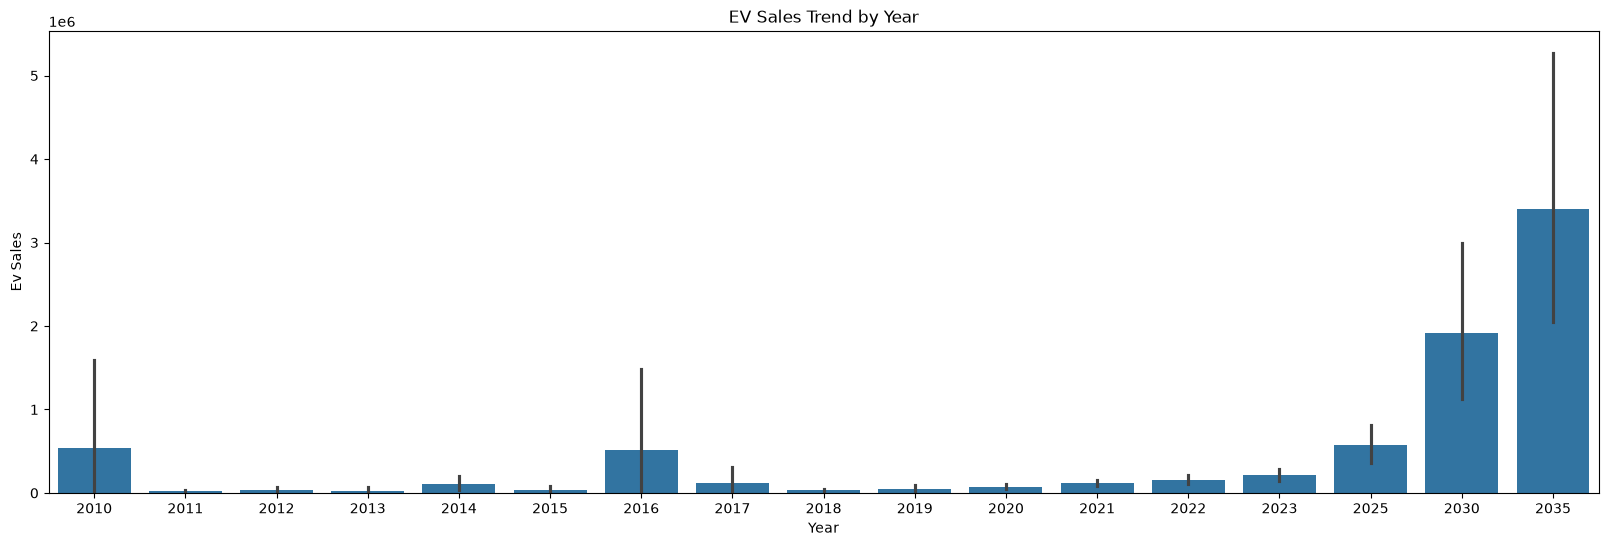

In [32]:
plt.figure(figsize=(20,6))
sns.barplot(x="year",y="value",data=df)
plt.title("EV Sales Trend by Year")
plt.xlabel('Year')
plt.ylabel('Ev Sales')
plt.show()

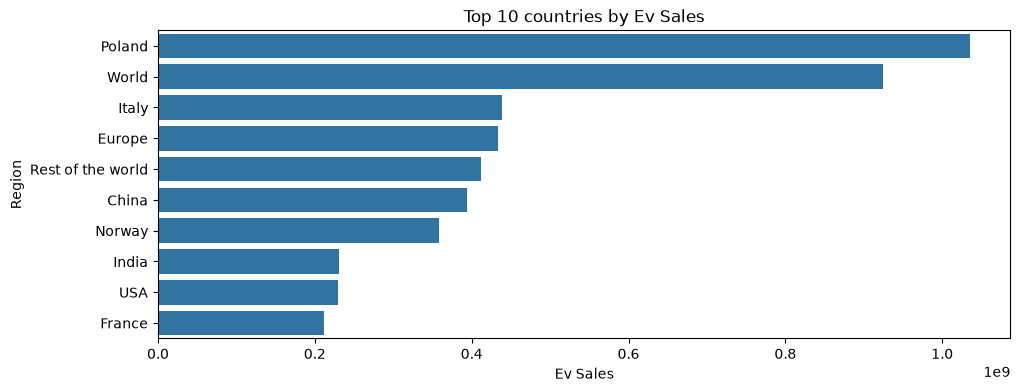

In [33]:
plt.figure(figsize=(11,4))
top10=df.groupby("region")["value"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="value",y="region",data=top10, errorbar=None)
plt.title("Top 10 countries by Ev Sales")
plt.xlabel('Ev Sales')
plt.ylabel('Region')
plt.show()


In [34]:
df.to_excel("ev_sales.xlsx", index=False)